# 18. Titanic Yolcu Verisi Görsel Analizi

**Kategori:** Veri Görselleştirme  
**Gerçek veri seti:** OpenML Titanic 40945  
**Veri kaynağı:** [https://www.openml.org/d/40945](https://www.openml.org/d/40945)  
**Amaç:** Yolcu özellikleri ile hayatta kalma oranları arasındaki örüntüleri görselleştirmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veri kalitesi

In [2]:
df = pd.read_csv(DATA_DIR / "titanic.csv", na_values="?")
df["survived"] = pd.to_numeric(df.survived, errors="coerce")
df["age"] = pd.to_numeric(df.age, errors="coerce")
df["fare"] = pd.to_numeric(df.fare, errors="coerce")
display(df.head())
print("Boyut:", df.shape, "| Tekrar:", df.duplicated().sum())
display(df.isna().mean().sort_values(ascending=False).head(10).to_frame("eksik_orani"))

Boyut: (1309, 14) | Tekrar: 0


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


,eksik_orani
body,0.907563
cabin,0.774637
boat,0.628724
home.dest,0.430863
age,0.200917
embarked,0.001528
fare,0.000764
sibsp,0.000000
name,0.000000
survived,0.000000


## 2. Hayatta kalma örüntüleri

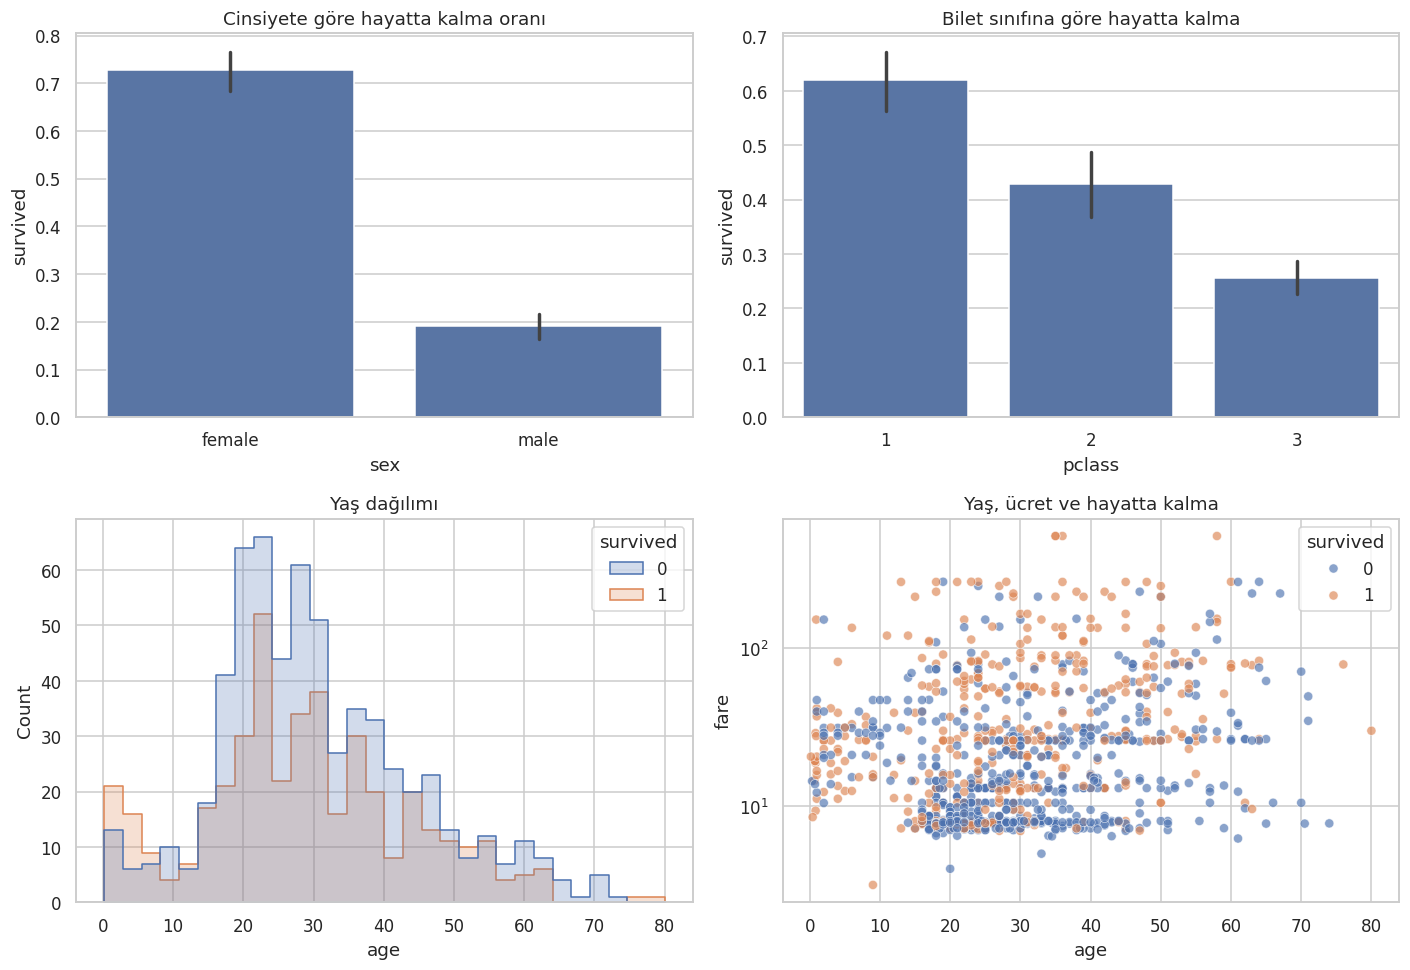

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0, 0])
axes[0, 0].set(title="Cinsiyete göre hayatta kalma oranı")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[0, 1])
axes[0, 1].set(title="Bilet sınıfına göre hayatta kalma")
sns.histplot(data=df, x="age", hue="survived", bins=30, element="step", ax=axes[1, 0])
axes[1, 0].set(title="Yaş dağılımı")
sns.scatterplot(data=df, x="age", y="fare", hue="survived", alpha=.65, ax=axes[1, 1])
axes[1, 1].set(yscale="log", title="Yaş, ücret ve hayatta kalma")
plt.tight_layout(); plt.show()

In [4]:
summary = df.groupby(["sex", "pclass"], dropna=False).agg(
    passengers=("survived", "size"),
    survival_rate=("survived", "mean"),
    median_age=("age", "median"),
    median_fare=("fare", "median"),
).round(3)
display(summary)
summary.to_csv(RESULT_DIR / "18_titanic_grup_ozeti.csv")
json.dump({"rows": int(len(df)), "overall_survival": float(df.survived.mean()),
           "missing_age": int(df.age.isna().sum())},
          open(RESULT_DIR / "18_titanic_eda.json", "w"), indent=2)

passengers  survival_rate  median_age  median_fare
sex    pclass                                                    
female 1              144          0.965        36.0       80.929
       2              106          0.887        28.0       23.000
       3              216          0.491        22.0       10.490
male   1              179          0.341        42.0       49.504
       2              171          0.146        29.5       13.000
       3              493          0.152        25.0        7.896

## Bulgular ve yorum sınırı

- Kadın yolcuların gözlenen hayatta kalma oranı erkeklerden yüksektir.
- Birinci sınıf yolcuların oranı alt sınıflardan yüksektir.
- Bu ilişkiler nedensellik kanıtı değildir; dönemin tahliye politikası, kabin konumu ve eksik kayıtlar
  gibi ortak etkenler bulunmaktadır.

Bu notebook yalnızca EDA/görselleştirme projesidir; model eğitilmedi.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **Titanic üzerinde temel EDA** biçimindedir.
Bu notebookta **eksik oranları, dört tamamlayıcı grafik, çoklu grup özeti ve nedensellik uyarısı** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).